# Probing phase transition

In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import h5py
import matplotlib.pyplot as plt
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.ising_dmrg import ising_dmrg, get_mps_probs

julia_bin = ['julia', '--sysimage', '/opt/julia/iiyama/sysimages/sys_itensors.so']

In [27]:
configs = []
configs.append('''
*-*-*-*-*╷
 * * * * *
*-*-*-*-*╵
''')
configs.append('''
*-*-*-*-*╷
 * * * * *
* * * * *╎
 * * * * *
*-*-*-*-*╵
''')
configs.append('''
*-*-*-*-*╷
 * * * * *
* * * * *╎
 * * * * *
* * * * *╎
 * * * * *
*-*-*-*-*╵
''')
configs.append('''
*-*-*-*-*╷
 * * * * *
* * * * *╎
 * * * * *
* * * * *╎
 * * * * *
* * * * *╎
 * * * * *
*-*-*-*-*╵
''')
configs.append('''
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
 * * * * * * * * * *
* * * * * * * * * *
''')

confignames = ['4x4', '4x8', '4x12', '4x16', '9x32']

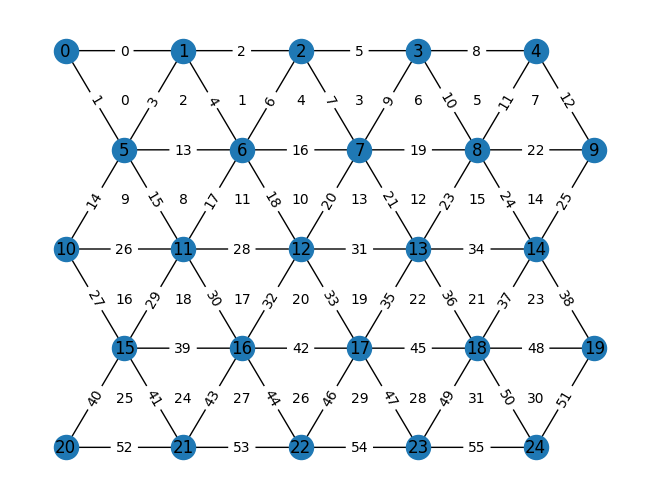

In [32]:
TriangularZ2Lattice(configs[1]).draw_graph();

In [3]:
num_plaquettes = np.empty(len(configs), dtype=int)
for iconf, config in enumerate(configs):
    lattice = TriangularZ2Lattice(config)
    num_plaquettes[iconf] = lattice.num_plaquettes

In [4]:
couplings = np.linspace(0., 4., 81)
energies = np.empty((len(configs),) + couplings.shape)
magnetizations = np.empty_like(energies)
probs_list = [[None] * len(couplings) for _ in range(len(configs))]

def make_filename(iconf, icp):
    dirname = f'/data/iiyama/2dz2/dmrg/coupling_scan_{num_plaquettes[iconf]}plaq'
    if not os.path.isdir(dirname):
        os.makedirs(dirname)

    return os.path.join(dirname, f'{couplings[icp]:.2f}.h5')

def dmrg_and_sparsity(iconf, icp):
    filename = make_filename(iconf, icp)
    hamiltonian = TriangularZ2Lattice(config).plaquette_dual().make_hamiltonian(couplings[icp])
    ising_dmrg(hamiltonian, filename, julia_bin=julia_bin)
    get_mps_probs(filename, num_samples=1_000_000, julia_bin=julia_bin)

def load_data(iconf, icp):
    filename = make_filename(iconf, icp)
    with h5py.File(filename, 'r') as source:
        energy = source['energy'][()]
        zexp = source['zexp'][()]
        # states = source['states'][()]
        try:
            probs = source['probs'][()]
        except KeyError:
            probs = []

    energies[iconf, icp] = energy
    magnetizations[iconf, icp] = np.mean(zexp)
    probs_list[iconf][icp] = probs


futures = {}
with ThreadPoolExecutor() as executor:
    for iconf, config in enumerate(configs):
        for icp, coupling in enumerate(couplings):
            try:
                load_data(iconf, icp)
            except (FileNotFoundError, KeyError):
                futures[(iconf, icp)] = executor.submit(dmrg_and_sparsity, iconf, icp)

for (iconf, icp), future in futures.items():
    future.result()
    load_data(iconf, icp)

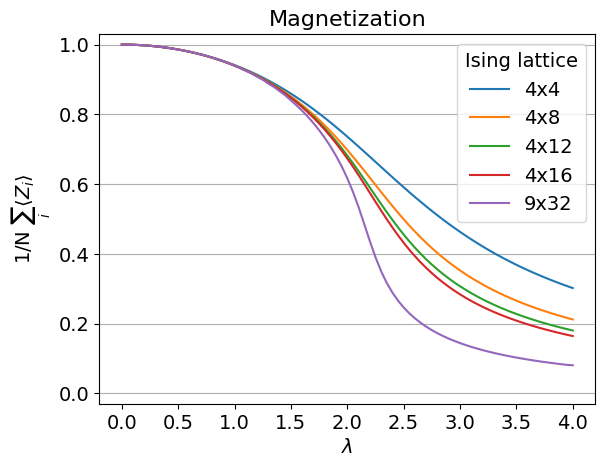

In [42]:
plt.plot(couplings, magnetizations.T, label=confignames)
plt.title('Magnetization', fontsize=16)
plt.xlabel(r'$\lambda$', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel(r'1/N $\sum_i \langle Z_i \rangle$', fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(-0.03, 1.03)
plt.grid(axis='y')
plt.legend(title='Ising lattice', fontsize=14, title_fontsize=14);

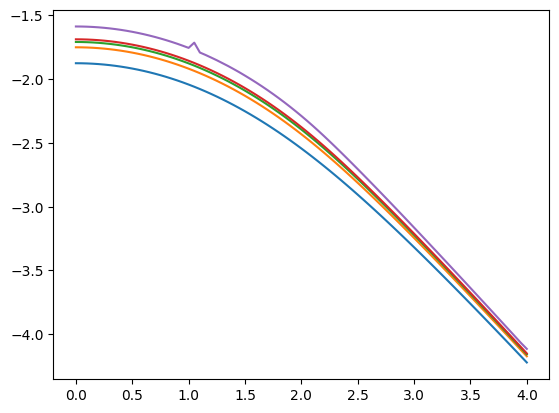

In [6]:
plt.plot(couplings, energies.T / num_plaquettes)

In [19]:
probs = np.sort(probs_list[0][10])
trunc = np.searchsorted(probs, 1.e-4)

In [20]:
probs

array([2.09015378e-09, 4.65162186e-09, 4.68828654e-09, 4.69612147e-09,
       4.72946507e-09, 4.73817530e-09, 1.04695697e-08, 1.18986892e-08,
       1.20260089e-08, 1.20401258e-08, 3.10251401e-08, 2.97314059e-07,
       2.97319575e-07, 2.97337189e-07, 2.97337225e-07, 2.97339450e-07,
       2.97339452e-07, 2.97360551e-07, 2.98107905e-07, 2.98111930e-07,
       2.98132306e-07, 2.99354262e-07, 2.99354768e-07, 2.99364685e-07,
       2.99375636e-07, 2.99388120e-07, 2.99402828e-07, 2.99403148e-07,
       2.99408888e-07, 3.00161064e-07, 3.00170431e-07, 3.00189887e-07,
       3.00194595e-07, 3.00195402e-07, 3.00196792e-07, 3.00199968e-07,
       3.00202171e-07, 3.00204883e-07, 3.00210653e-07, 3.00212196e-07,
       3.00218475e-07, 3.00223854e-07, 3.00224356e-07, 3.00239587e-07,
       3.00973074e-07, 3.01025171e-07, 3.01026371e-07, 3.01410466e-07,
       3.01414341e-07, 3.01432038e-07, 3.01435655e-07, 3.01443187e-07,
       3.01466690e-07, 3.02194797e-07, 3.02221577e-07, 3.02236652e-07,
      

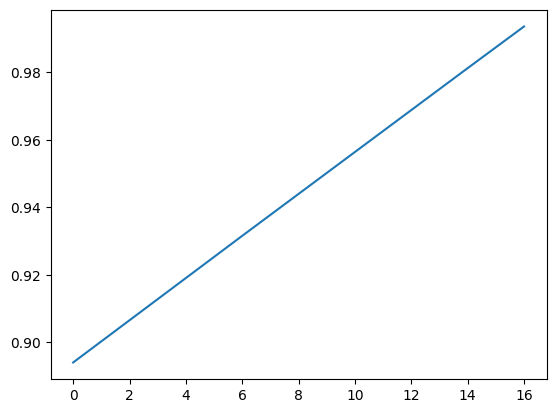

In [21]:
plt.plot(np.cumsum(probs[trunc:][::-1]))

In [12]:
probs.shape

(61413,)

In [15]:
# masses = np.empty_like(energies)
supports = np.empty_like(energies, dtype=int)
for iconf, lst in enumerate(probs_list):
    for icp, probs in enumerate(lst):
        probs = np.sort(probs)[::-1]
        cumprobs = np.cumsum(probs)
        supports[iconf, icp] = np.searchsorted(cumprobs, 1 - 1.e-3)

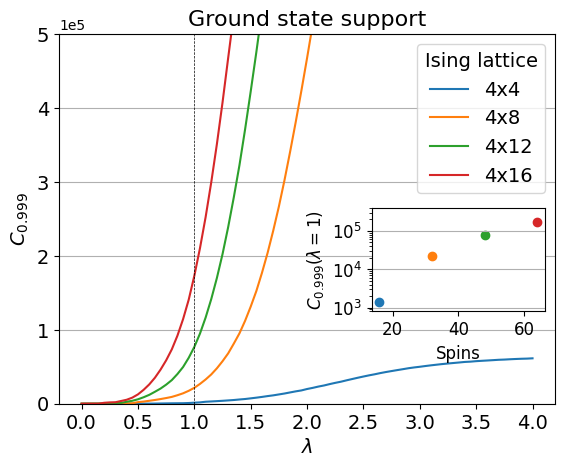

In [96]:
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.plot(couplings, supports.T[:, :-1], label=confignames[:-1])
plt.title('Ground state support', fontsize=16)
plt.xlabel(r'$\lambda$', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel(r'$C_{0.999}$', fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0., 5.e+5)
plt.axvline(1., linestyle='--', color='k', linewidth=0.5)
plt.grid(axis='y')
plt.legend(title='Ising lattice', title_fontsize=14, fontsize=14)

inset = plt.gca().inset_axes((0.63, 0.25, 0.35, 0.28))
cp1 = np.argmin(np.abs(couplings - 1.))
# plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
for ip, npl in enumerate([16, 32, 48, 64]):
    inset.scatter([npl], supports[ip:ip + 1, cp1])
    inset.set_xlabel('Spins', fontsize=12)
    inset.set_ylabel(r'$C_{0.999}(\lambda=1)$', fontsize=12)
    inset.tick_params(labelsize=12)
    inset.set_ylim(8.e+2, 4.e+5)
    inset.set_yscale('log')
    inset.grid(visible=True, axis='y')

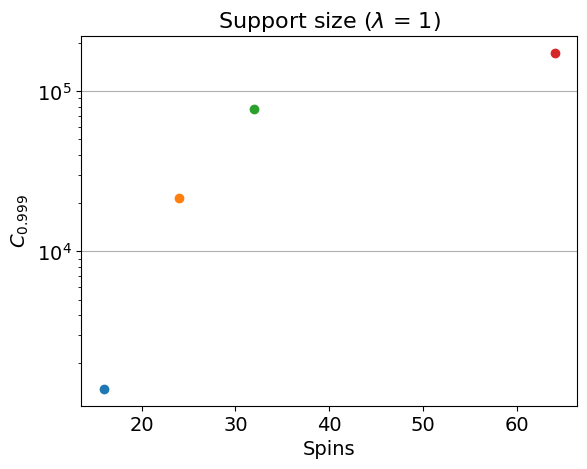

In [ ]:
from scipy.optimize import curve_fit

cp1 = np.argmin(np.abs(couplings - 1.))
# plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
for ip, npl in enumerate([16, 32, 48, 64]):
    plt.scatter([npl], supports[ip:ip + 1, cp1], label=confignames[ip])
plt.title(r'Support size ($\lambda$ = 1)', fontsize=16)
plt.xlabel('Spins', fontsize=14)
plt.xticks(fontsize=14)
plt.ylabel('$C_{0.999}$', fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(0., 2.e+5)
plt.yscale('log')
plt.grid(axis='y')
#plt.legend(title='Ising lattice', fontsize=14, title_fontsize=14, loc='lower right');

In [70]:
from matplotlib import rcParams
next(iter(rcParams['axes.prop_cycle']))

{'color': '#1f77b4'}

In [50]:
res

(array([ 9.99999999e-01,  3.52141239e-16, -7.70010319e+03]),
 array([[ 1.07803330e-04, -1.63431541e-10,  9.77461288e+09],
        [-1.63431541e-10,  2.47764782e-16, -1.48184666e+04],
        [ 9.77461288e+09, -1.48184666e+04,  2.41044635e+24]]))